In [2]:
# TENSORLOW (Google)
# Constants
import tensorflow as tf

print(tf.ones(shape=(2, 1)))
print(tf.zeros(shape=(2, 1)))
print(tf.constant([1, 2, 3], dtype="float32"))

tf.Tensor(
[[1.]
 [1.]], shape=(2, 1), dtype=float32)
tf.Tensor(
[[0.]
 [0.]], shape=(2, 1), dtype=float32)
tf.Tensor([1. 2. 3.], shape=(3,), dtype=float32)


In [3]:
# Random Tensors
import tensorflow as tf

x = tf.random.normal(shape=(3, 1), mean=0., stddev=1.)
print(x)

x = tf.random.uniform(shape=(3, 1), minval=0., maxval=1.)
print(x)

tf.Tensor(
[[ 1.0255059 ]
 [-0.6554401 ]
 [-0.24173817]], shape=(3, 1), dtype=float32)
tf.Tensor(
[[0.1031872 ]
 [0.7133473 ]
 [0.56754506]], shape=(3, 1), dtype=float32)


In [4]:
# Assignment of variables
import numpy as np

# With numpy
# You can reassign
x = np.ones(shape=(2, 2))
print(x)
x[0, 0] = 0
print(x)

[[1. 1.]
 [1. 1.]]
[[0. 1.]
 [1. 1.]]


In [5]:
import tensorflow as tf

# With tensorflow
# You cannot reassign -> error
x = tf.ones(shape=(2, 2))
x[0, 0] = 0.


TypeError: 'tensorflow.python.framework.ops.EagerTensor' object does not support item assignment

In [6]:
import tensorflow as tf

# With tensorflow
# You have to use variables that first need to be assigned an initial value
v = tf.Variable(initial_value=tf.random.normal(shape=(3, 1)))
print(v)

# Then you can reassign
# Reassign whole vector
v.assign(tf.ones((3, 1)))
print(v)

# Reassign subset of vector
v[0, 0].assign(3.)
print(v)

# Adding values
v.assign_add(tf.ones((3, 1)))
print(v)

<tf.Variable 'Variable:0' shape=(3, 1) dtype=float32, numpy=
array([[-1.1787227 ],
       [ 1.798926  ],
       [ 0.81075656]], dtype=float32)>
<tf.Variable 'Variable:0' shape=(3, 1) dtype=float32, numpy=
array([[1.],
       [1.],
       [1.]], dtype=float32)>
<tf.Variable 'Variable:0' shape=(3, 1) dtype=float32, numpy=
array([[3.],
       [1.],
       [1.]], dtype=float32)>
<tf.Variable 'Variable:0' shape=(3, 1) dtype=float32, numpy=
array([[4.],
       [2.],
       [2.]], dtype=float32)>


In [7]:
import tensorflow as tf

# Tensor operations
a = tf.ones((2, 2))
print(a)

b = tf.square(a)
print(b)

c = tf.sqrt(b)
print(c)

d = b + c
print(d)

e = tf.matmul(a, b)
print(e)

f = tf.concat((a, b), axis=0)
print(f)

# _______________________________

a = tf.ones((2, 2))
b = tf.ones((2, 2))
c = a + b
print(c)

d = tf.square(c)
print(d)

e = tf.sqrt(d)
print(e)

tf.Tensor(
[[1. 1.]
 [1. 1.]], shape=(2, 2), dtype=float32)
tf.Tensor(
[[1. 1.]
 [1. 1.]], shape=(2, 2), dtype=float32)
tf.Tensor(
[[1. 1.]
 [1. 1.]], shape=(2, 2), dtype=float32)
tf.Tensor(
[[2. 2.]
 [2. 2.]], shape=(2, 2), dtype=float32)
tf.Tensor(
[[2. 2.]
 [2. 2.]], shape=(2, 2), dtype=float32)
tf.Tensor(
[[1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]], shape=(4, 2), dtype=float32)
tf.Tensor(
[[2. 2.]
 [2. 2.]], shape=(2, 2), dtype=float32)
tf.Tensor(
[[4. 4.]
 [4. 4.]], shape=(2, 2), dtype=float32)
tf.Tensor(
[[2. 2.]
 [2. 2.]], shape=(2, 2), dtype=float32)


In [8]:
# Using GradientTape
import tensorflow as tf

input_var = tf.Variable(initial_value=3.)
with tf.GradientTape() as tape:
    result = tf.square(input_var)
gradient = tape.gradient(result, input_var)

In [9]:
# Second order gradients
time = tf.Variable(0.)
with tf.GradientTape() as outer_tape:
    with tf.GradientTape() as inner_tape:
        position = 4.9 * time ** 2
    speed = inner_tape.gradient(position, time)
acceleration = outer_tape.gradient(speed, time)
print(time)
print(speed)
print(acceleration)

<tf.Variable 'Variable:0' shape=() dtype=float32, numpy=0.0>
tf.Tensor(0.0, shape=(), dtype=float32)
tf.Tensor(9.8, shape=(), dtype=float32)


In [10]:
# Using compilation to improve performance
# Default graph-mode
@tf.function
def dense(inputs, W, b):
    return tf.nn.relu(tf.matmul(inputs, W) + b)


# Using XLA compiler -> faster than graph-mode
@tf.function(jit_compile=True)
def dense(inputs, W, b):
    return tf.nn.relu(tf.matmul(inputs, W) + b)

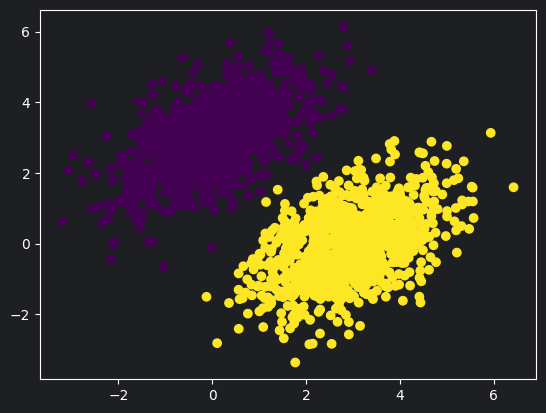

In [11]:
import matplotlib.pyplot as plt

# Complete linear classifier

# Two classes of random points
num_samples_per_class = 1000
negative_samples = np.random.multivariate_normal(
    mean=[0, 3], cov=[[1, 0.5], [0.5, 1]], size=num_samples_per_class)
positive_samples = np.random.multivariate_normal(
    mean=[3, 0], cov=[[1, 0.5], [0.5, 1]], size=num_samples_per_class)

# Put all in one array
inputs = np.vstack((negative_samples, positive_samples)).astype(np.float32)

targets = np.vstack((np.zeros((num_samples_per_class, 1), dtype="float32"),
                     np.ones((num_samples_per_class, 1), dtype="float32")))
# plt.scatter(x-value, y-value, target) -> the first 1000 data points (negative_samples) have target value 0, the others 1
plt.scatter(inputs[:, 0], inputs[:, 1], c=targets[:, 0])
plt.savefig("linear_model_inputs.png", dpi=300)

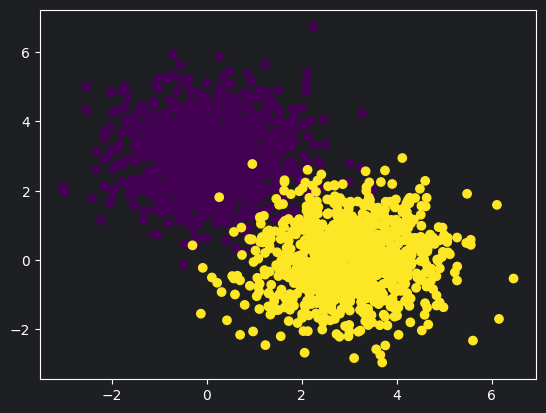

In [12]:
# Different covariance matrices
# Identity covariance (var(x) = var(y), cov(x,y)=0)
# Size of circle = 1
num_samples_per_class = 1000
negative_samples = np.random.multivariate_normal(
    mean=[0, 3],
    cov=[[1, 0], [0, 1]],
    size=num_samples_per_class)

positive_samples = np.random.multivariate_normal(
    mean=[3, 0],
    cov=[[1, 0], [0, 1]],
    size=num_samples_per_class)

# Put all in one array
inputs = np.vstack((negative_samples, positive_samples)).astype(np.float32)

targets = np.vstack((np.zeros((num_samples_per_class, 1), dtype="float32"),
                     np.ones((num_samples_per_class, 1), dtype="float32")))

plt.scatter(inputs[:, 0], inputs[:, 1], c=targets[:, 0])
plt.savefig("linear_model_inputs.png", dpi=300)

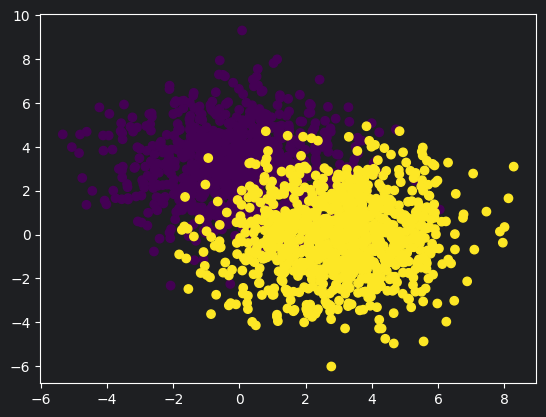

In [13]:
# Different covariance matrices
# Identity covariance (var(x) = var(y), cov(x,y)=0)
# Larger circles
num_samples_per_class = 1000

negative_samples = np.random.multivariate_normal(
    mean=[0, 3],
    cov=[[3, 0], [0, 3]],
    size=num_samples_per_class)

positive_samples = np.random.multivariate_normal(
    mean=[3, 0],
    cov=[[3, 0], [0, 3]],
    size=num_samples_per_class)

# Put all in one array
inputs = np.vstack((negative_samples, positive_samples)).astype(np.float32)

targets = np.vstack((np.zeros((num_samples_per_class, 1), dtype="float32"),
                     np.ones((num_samples_per_class, 1), dtype="float32")))

plt.scatter(inputs[:, 0], inputs[:, 1], c=targets[:, 0])
plt.savefig("linear_model_inputs.png", dpi=300)

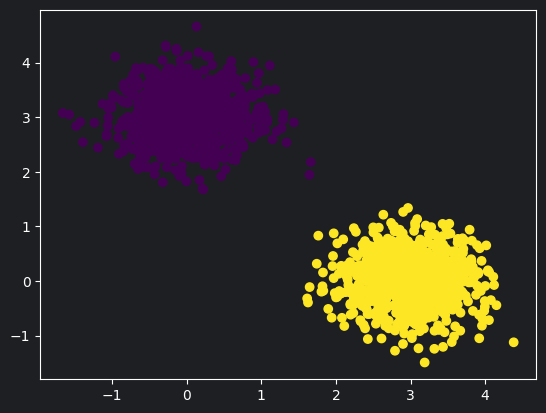

In [14]:
# Different covariance matrices
# Identity covariance (var(x) = var(y), cov(x,y)=0)
# Smaller circles
num_samples_per_class = 1000

negative_samples = np.random.multivariate_normal(
    mean=[0, 3],
    cov=[[0.2, 0], [0, 0.2]],
    size=num_samples_per_class)

positive_samples = np.random.multivariate_normal(
    mean=[3, 0],
    cov=[[0.2, 0], [0, 0.2]],
    size=num_samples_per_class)

# Put all in one array
inputs = np.vstack((negative_samples, positive_samples)).astype(np.float32)

targets = np.vstack((np.zeros((num_samples_per_class, 1), dtype="float32"),
                     np.ones((num_samples_per_class, 1), dtype="float32")))

plt.scatter(inputs[:, 0], inputs[:, 1], c=targets[:, 0])
plt.savefig("linear_model_inputs.png", dpi=300)

In [18]:
# Create classifier
negative_samples = np.random.multivariate_normal(
    mean=[0, 3], cov=[[1, 0.5], [0.5, 1]], size=num_samples_per_class)
positive_samples = np.random.multivariate_normal(
    mean=[3, 0], cov=[[1, 0.5], [0.5, 1]], size=num_samples_per_class)

# Put all in one array
inputs = np.vstack((negative_samples, positive_samples)).astype(np.float32)

targets = np.vstack((np.zeros((num_samples_per_class, 1), dtype="float32"),
                     np.ones((num_samples_per_class, 1), dtype="float32")))

input_dim = 2
output_dim = 1
W = tf.Variable(initial_value=tf.random.uniform(shape=(input_dim, output_dim)))
b = tf.Variable(initial_value=tf.zeros(shape=(output_dim,)))

# Forward pass function
def model(inputs, W, b):
    return tf.matmul(inputs, W) + b

# Loss function
def mean_squared_error(targets, predictions):
    per_sample_losses = tf.square(targets - predictions)
    return tf.reduce_mean(per_sample_losses)

# Training step function
learning_rate = 0.1

@tf.function(jit_compile=True)
def training_step(inputs, targets, W, b):
    with tf.GradientTape() as tape:
        predictions = model(inputs, W, b)
        loss = mean_squared_error(predictions, targets)
    grad_loss_wrt_W, grad_loss_wrt_b = tape.gradient(loss, [W, b])
    W.assign_sub(grad_loss_wrt_W * learning_rate)
    b.assign_sub(grad_loss_wrt_b * learning_rate)
    return loss

for step in range(400):
    loss = training_step(inputs, targets, W, b)
    print(f"Loss at step {step}: {loss:.4f}")
    print(f"W: {W}, b: {b}")

predictions = model(inputs, W, b)
# plt.scatter(inputs[:, 0], inputs[:, 1], c=predictions[:, 0] > 0.5)
# plt.savefig("linear_model_predictions.png", dpi=300)
#
# # Plot the line
# x = np.linspace(-1, 4, 100)
# y = - W[0] / W[1] * x + (0.5 - b) / W[1]
# plt.plot(x, y, "-r")
# plt.scatter(inputs[:, 0], inputs[:, 1], c=predictions[:, 0] > 0.5)

Loss at step 0: 1.8885
W: <tf.Variable 'Variable:0' shape=(2, 1) dtype=float32, numpy=
array([[ 0.1937097 ],
       [-0.09219738]], dtype=float32)>, b: <tf.Variable 'Variable:0' shape=(1,) dtype=float32, numpy=array([-0.20556895], dtype=float32)>
Loss at step 1: 0.3459
W: <tf.Variable 'Variable:0' shape=(2, 1) dtype=float32, numpy=
array([[0.3494404 ],
       [0.05824243]], dtype=float32)>, b: <tf.Variable 'Variable:0' shape=(1,) dtype=float32, numpy=array([-0.09359013], dtype=float32)>
Loss at step 2: 0.1482
W: <tf.Variable 'Variable:0' shape=(2, 1) dtype=float32, numpy=
array([[ 0.28434503],
       [-0.00500117]], dtype=float32)>, b: <tf.Variable 'Variable:0' shape=(1,) dtype=float32, numpy=array([-0.09574008], dtype=float32)>
Loss at step 3: 0.1161
W: <tf.Variable 'Variable:0' shape=(2, 1) dtype=float32, numpy=
array([[0.29840642],
       [0.00788486]], dtype=float32)>, b: <tf.Variable 'Variable:0' shape=(1,) dtype=float32, numpy=array([-0.05900623], dtype=float32)>
Loss at step 4: 